In [40]:
import pandas as pd
import networkx as nx

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_excel("/content/drive/MyDrive/P2P_EventLog_ProcessMining.xlsx")

# Convert timestamp (important!)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort data
df = df.sort_values(by=["Case ID", "Timestamp"])

edges = []

# Build transitions
for case, group in df.groupby("Case ID"):
    activities = list(group["Activity"])
    for i in range(len(activities) - 1):
        edges.append((activities[i], activities[i+1]))

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Centrality (importance of nodes)
centrality = nx.degree_centrality(G)

# Get top bottlenecks
top_bottlenecks = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

# Convert to dictionary
centrality_dict = dict(top_bottlenecks)

print("Top Bottleneck Activities (Network Centrality):")
for act, score in centrality_dict.items():
    print(f"{act}: {score:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Top Bottleneck Activities (Network Centrality):
Purchase Order Approved: 0.2500
Purchase Requisition Approved: 0.1250
Request for Quotation Sent: 0.1250
Quotation Received: 0.1250
Purchase Order Created: 0.1250


In [15]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.6 MB/s eta 0:00:00


In [16]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_excel("/content/drive/MyDrive/P2P_EventLog_ProcessMining.xlsx")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Case ID,Activity,Timestamp,Resource,Department,Supplier,Item Category,PO Value (LKR),Scenario Type
0,PO-2024-0001,Purchase Requisition Created,2024-11-25 01:18:26,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
1,PO-2024-0001,Purchase Requisition Approved,2024-11-26 13:22:41,AP003-Priya Wijesinghe,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
2,PO-2024-0001,Request for Quotation Sent,2024-11-26 14:59:12,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
3,PO-2024-0001,Quotation Received,2024-11-29 07:29:28,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
4,PO-2024-0001,Purchase Order Created,2024-11-29 08:38:24,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal


In [17]:
# Rename columns for PM4Py compatibility
df.rename(columns={
    "Case ID": "case:concept:name",
    "Activity": "concept:name",
    "Timestamp": "time:timestamp"
}, inplace=True)

# Convert timestamp
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

df.head()

,case:concept:name,concept:name,time:timestamp,Resource,Department,Supplier,Item Category,PO Value (LKR),Scenario Type
0,PO-2024-0001,Purchase Requisition Created,2024-11-25 01:18:26,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
1,PO-2024-0001,Purchase Requisition Approved,2024-11-26 13:22:41,AP003-Priya Wijesinghe,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
2,PO-2024-0001,Request for Quotation Sent,2024-11-26 14:59:12,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
3,PO-2024-0001,Quotation Received,2024-11-29 07:29:28,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal
4,PO-2024-0001,Purchase Order Created,2024-11-29 08:38:24,B001-Amal Silva,Procurement,Sup-001 Textile Hub,Thread & Accessories,64998.5,Normal


In [23]:
import pm4py

event_log = pm4py.format_dataframe(df,
    case_id='case:concept:name',
    activity_key='concept:name',
    timestamp_key='time:timestamp')

event_log = pm4py.convert_to_event_log(event_log)

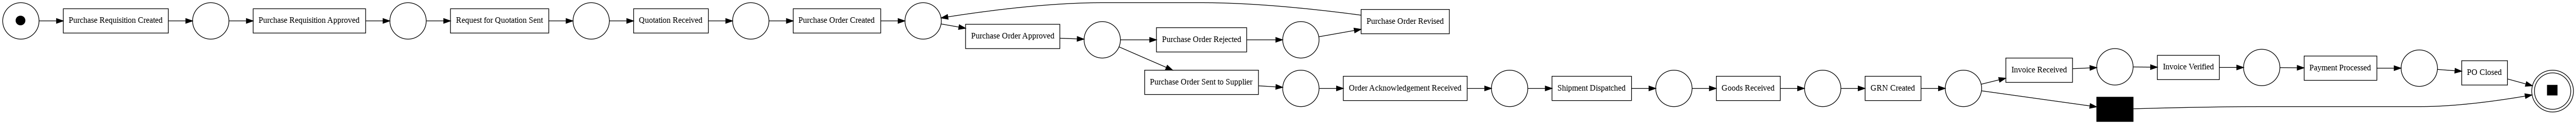

In [31]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
import pm4py

# Step 1: Get process tree
process_tree = inductive_miner.apply(event_log)

# Step 2: Convert to Petri net
net, initial_marking, final_marking = pt_converter.apply(process_tree)

# Step 3: Visualize
pm4py.view_petri_net(net, initial_marking, final_marking)

In [32]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

replay_result = token_replay.apply(event_log, net, initial_marking, final_marking)

fitness = sum([x["trace_fitness"] for x in replay_result]) / len(replay_result)

print("Average Fitness:", fitness)

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

Average Fitness: 1.0


In [33]:
# Calculate activity duration gaps
df_sorted = df.sort_values(by=["case:concept:name", "time:timestamp"])

df_sorted['next_time'] = df_sorted.groupby('case:concept:name')['time:timestamp'].shift(-1)

df_sorted['duration'] = (df_sorted['next_time'] - df_sorted['time:timestamp']).dt.total_seconds()

# Average duration per activity
bottlenecks = df_sorted.groupby("concept:name")["duration"].mean().sort_values(ascending=False)

print(bottlenecks.head(10))

concept:name
Order Acknowledgement Received     477333.668000
GRN Created                        473971.885886
Invoice Verified                   314175.713213
Request for Quotation Sent         308936.474667
Purchase Order Sent to Supplier    237169.278667
Purchase Order Created             230756.549333
Purchase Order Revised             179611.323944
Purchase Requisition Created       152565.560000
Invoice Received                   108911.328829
Goods Received                      80692.932000
Name: duration, dtype: float64


In [34]:
# Identify most frequent path
variant_df = pm4py.get_variants_as_tuples(event_log)

for variant, freq in list(variant_df.items())[:5]:
    print(variant, ":", freq)

('Purchase Requisition Created', 'Purchase Requisition Approved', 'Request for Quotation Sent', 'Quotation Received', 'Purchase Order Created', 'Purchase Order Approved', 'Purchase Order Sent to Supplier', 'Order Acknowledgement Received', 'Shipment Dispatched', 'Goods Received', 'GRN Created', 'Invoice Received', 'Invoice Verified', 'Payment Processed', 'PO Closed') : [{'attributes': {'concept:name': 'PO-2024-0001'}, 'events': [{'concept:name': 'Purchase Requisition Created', 'time:timestamp': Timestamp('2024-11-25 01:18:26+0000', tz='UTC'), 'Resource': 'B001-Amal Silva', 'Department': 'Procurement', 'Supplier': 'Sup-001 Textile Hub', 'Item Category': 'Thread & Accessories', 'PO Value (LKR)': 64998.5, 'Scenario Type': 'Normal', '@@index': 0, '@@case_index': 0}, '..', {'concept:name': 'PO Closed', 'time:timestamp': Timestamp('2024-12-23 09:08:33+0000', tz='UTC'), 'Resource': 'B001-Amal Silva', 'Department': 'Procurement', 'Supplier': 'Sup-001 Textile Hub', 'Item Category': 'Thread & Ac

In [35]:
# Example: grouping by multiple objects (conceptual)
df.groupby(["case:concept:name", "Resource"]).size()

case:concept:name  Resource                  
PO-2024-0001       AP003-Priya Wijesinghe        2
                   B001-Amal Silva               6
                   FIN001-Ruwan Dissanayake      1
                   FIN002-Malika Gunasekara      2
                   GRN001-Lasantha Jayasuriya    2
                                                ..
PO-2024-0750       FIN001-Ruwan Dissanayake      1
                   FIN002-Malika Gunasekara      2
                   GRN002-Nuwan Pathirana        2
                   LOG001-Thilak Bandara         1
                   LOG002-Suresh Mendis          1
Length: 5467, dtype: int64

In [37]:
# Split dataset into two parts
df_part1 = df.iloc[:len(df)//2]
df_part2 = df.iloc[len(df)//2:]

# Combine as local logs
local_logs = [df_part1, df_part2]

# Aggregate insights
results = [log.groupby("concept:name").size() for log in local_logs]

for i, res in enumerate(results):
    print(f"\n--- Results from log {i+1} ---")
    print(res.head())


--- Results from log 1 ---
concept:name
GRN Created                       374
Goods Received                    374
Invoice Received                  330
Invoice Verified                  330
Order Acknowledgement Received    375
dtype: int64

--- Results from log 2 ---
concept:name
GRN Created                       376
Goods Received                    376
Invoice Received                  336
Invoice Verified                  336
Order Acknowledgement Received    375
dtype: int64
